In [9]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import zarr
import tqdm
import sklearn

## Model Architecture

In [3]:
class UNet3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=3):
        super().__init__()
        self.enc1 = self._conv_block(in_channels, 16)
        self.enc2 = self._conv_block(16, 32)
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = self._conv_block(32, 64)
        self.upconv2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(64, 32)
        self.upconv1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(32, 16)
        self.final_conv = nn.Conv3d(16, out_channels, kernel_size=1)
        
        # Initialize final layer to predict zero displacement
        self.final_conv.weight.data.zero_()
        self.final_conv.bias.data.zero_()

    def _conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv3d(in_c, out_c, 3, 1, 1, bias=False),
            nn.InstanceNorm3d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_c, out_c, 3, 1, 1, bias=False),
            nn.InstanceNorm3d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x_fixed, x_moving):
        x = torch.cat([x_fixed, x_moving], dim=1)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.upconv2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.final_conv(d1)

## Dataset Loader

In [4]:
class SupervisedDisplacementDataset(Dataset):
    def __init__(self, moving_path, fixed_path, dvf_gt_path):
        super().__init__()
        self.moving_arr = zarr.open(moving_path, mode='r')
        self.fixed_arr = zarr.open(fixed_path, mode='r')
        self.dvf_gt_arr = zarr.open(dvf_gt_path, mode='r')
        
        # Check for consistent lengths
        self.num_images = self.moving_arr.shape[3]
        assert self.fixed_arr.shape[3] == self.num_images and self.dvf_gt_arr.shape[3] == self.num_images, \
            "The number of images and DVFs must match across all Zarr arrays."
            
        # Pre-calculate padding requirements
        self.original_shape = self.moving_arr.shape[:3] # H, W, D
        self.padded_shape = list(self.original_shape)
        for i in range(3):
            if self.padded_shape[i] % 4 != 0:
                self.padded_shape[i] = (self.padded_shape[i] // 4 + 1) * 4
    
    def __len__(self):
        return self.num_images

    def _pad_tensor(self, tensor):
        # Assumes tensor is (C, D, H, W)
        pad_d = self.padded_shape[2] - tensor.shape[1]
        pad_h = self.padded_shape[0] - tensor.shape[2]
        pad_w = self.padded_shape[1] - tensor.shape[3]
        padding = (pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2, pad_d // 2, pad_d - pad_d // 2)
        return F.pad(tensor, padding, "constant", 0)

    def __getitem__(self, idx):
        # Load data from Zarr arrays as numpy arrays
        moving_np = self.moving_arr[..., idx]
        fixed_np = self.fixed_arr[..., idx]
        dvf_gt_np = self.dvf_gt_arr[:, :, :, idx, :] # Shape (H, W, D, 3)

        # Convert to tensors
        moving_tensor = torch.from_numpy(moving_np.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
        fixed_tensor = torch.from_numpy(fixed_np.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
        dvf_gt_tensor = torch.from_numpy(dvf_gt_np.astype(np.float32)).permute(3, 2, 0, 1)

        # Apply padding
        moving_padded = self._pad_tensor(moving_tensor)
        fixed_padded = self._pad_tensor(fixed_tensor)
        dvf_gt_padded = self._pad_tensor(dvf_gt_tensor)

        return moving_padded, fixed_padded, dvf_gt_padded

## Training

Data pathes

In [7]:
MOVING_PATH = "/mnt/dev_rep/repos/MRI-MoCoCo/DCE_codeset/DCE_codeset/MRI-Datasets/DCE/DCE"
FIXED_PATH = "../DCE_codeset/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
DVF_GT_PATH = "../DCE_codeset/MRI-Datasets/mdreg_DCE_fitting_results/transfo_zarr_2.zarr"

In [20]:
MODEL_LOAD_PATH = "dvf_model_01_1e-5_100ep.pth"
MODEL_SAVE_PATH = "./dvf_model_01_1e-5_200ep.pth"
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
NUM_EPOCHS = 150
VALIDATION_SPLIT = 0.2
RANDOM_SEED = 42

full_dataset = SupervisedDisplacementDataset(MOVING_PATH, FIXED_PATH, DVF_GT_PATH)
print(full_dataset.fixed_arr.shape)

all_indices = list(range(len(full_dataset)))

# --- 3. Teile die INDIZES mit train_test_split auf ---
train_indices, val_indices = sklearn.model_selection.train_test_split(
    all_indices,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_SEED,
    shuffle=True  # Mische die Daten vor der Aufteilung (empfohlen)
)

train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)


(256, 256, 50, 1000)


/tmp/ipykernel_1459/1690545007.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


Loaded weights from dvf_model_01_1e-5_100ep.pth
Starting supervised training on cuda...


Training:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_1459/1690545007.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
/tmp/ipykernel_1459/1690545007.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch 1/150 - Train Loss: 0.015101, Val Loss: 0.012588
  -> New best model saved to ./dvf_model_01_1e-5_200ep.pth


...

Epoch 146/150 - Train Loss: 0.000983, Val Loss: 0.001069


Epoch 147/150 - Train Loss: 0.000942, Val Loss: 0.000908


Epoch 148/150 - Train Loss: 0.000855, Val Loss: 0.000940


Epoch 149/150 - Train Loss: 0.000871, Val Loss: 0.000933


Epoch 150/150 - Train Loss: 0.000873, Val Loss: 0.001017

--- Training Summary ---
⏱️ Total Training Time: 347 minutes 56 seconds
Final Train Loss: 0.000873
Final Validation Loss: 0.001017
✅ Best Validation Loss Achieved: 0.000894


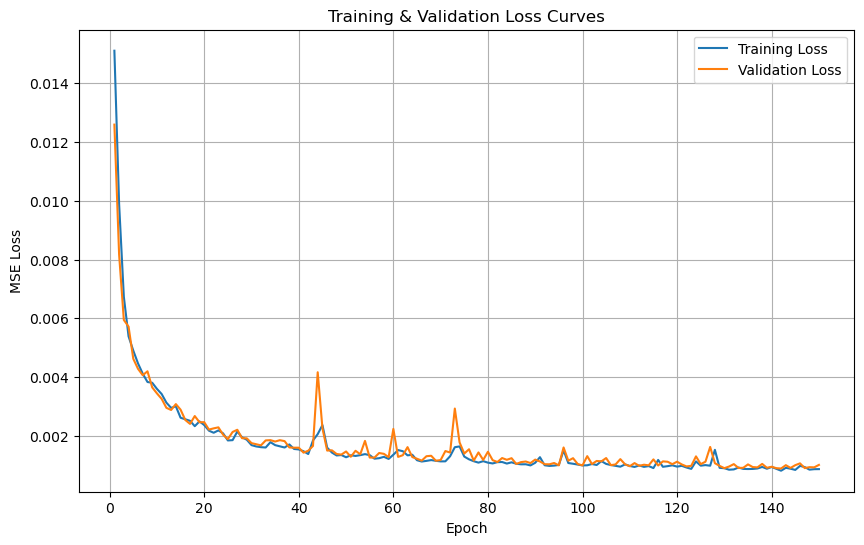

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
import time
import os
import copy
import matplotlib.pyplot as plt

# Annahme: Ihre UNet3D-Klasse und die DataLoader (train_loader, val_loader) sind bereits definiert.

# ==================================================================
# 1. ERWEITERTE FUNKTIONEN FÜR TRAINING & VALIDIERUNG
# ==================================================================

def train_one_epoch(model, loader, optimizer, loss_fn, scaler, device):
    """Führt eine Trainingsepoche durch und gibt den durchschnittlichen Loss zurück."""
    model.train()
    total_loss = 0.0
    progress_bar = tqdm.tqdm(loader, desc="Training", leave=False)
    
    for moving, fixed, dvf_gt in progress_bar:
        moving, fixed, dvf_gt = moving.to(device), fixed.to(device), dvf_gt.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            predicted_dvf = model(fixed, moving)
            loss = loss_fn(predicted_dvf, dvf_gt)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.6f}")
        
    return total_loss / len(loader)

def validate(model, loader, loss_fn, device):
    """Evaluiert das Modell auf dem Validierungsdatensatz und gibt den durchschnittlichen Loss zurück."""
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for moving, fixed, dvf_gt in loader:
            moving, fixed, dvf_gt = moving.to(device), fixed.to(device), dvf_gt.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                predicted_dvf = model(fixed, moving)
                loss = loss_fn(predicted_dvf, dvf_gt)
            total_loss += loss.item()
            
    return total_loss / len(loader)

# ==================================================================
# 2. HAUPTSKRIPT: INITIALISIERUNG
# ==================================================================

# --- Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet3D().to(device)

if os.path.exists(MODEL_LOAD_PATH):
    model.load_state_dict(torch.load(MODEL_LOAD_PATH, map_location=device))
    print(f"Loaded weights from {MODEL_LOAD_PATH}")
    
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

# NEU: Listen zum Speichern der Loss-Werte für den Plot
train_losses = []
val_losses = []
best_val_loss = float('inf')

# ==================================================================
# 3. DIE HAUPT-TRAININGSSCHLEIFE
# ==================================================================

print(f"Starting supervised training on {device}...")
start_time = time.time() # NEU: Startzeit messen

for epoch in range(NUM_EPOCHS):
    
    # Führe Training und Validierung durch
    avg_train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler, device)
    avg_val_loss = validate(model, val_loader, loss_fn, device) # val_loader hier verwenden
    
    # Speichere die Loss-Werte
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")
    
    # NEU: Checkpointing - Speichere das Modell nur, wenn es sich verbessert hat
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  -> New best model saved to {MODEL_SAVE_PATH}")

end_time = time.time() # NEU: Endzeit messen
total_training_time = end_time - start_time

# ==================================================================
# 4. ERGEBNISSE ANZEIGEN
# ==================================================================

print("\n--- Training Summary ---")

# --- Trainingszeit ---
mins, secs = divmod(total_training_time, 60)
print(f"⏱️ Total Training Time: {int(mins)} minutes {int(secs)} seconds")

# --- Finale Loss-Werte ---
final_train_loss = train_losses[-1]
final_val_loss = val_losses[-1]
print(f"Final Train Loss: {final_train_loss:.6f}")
print(f"Final Validation Loss: {final_val_loss:.6f}")
print(f"✅ Best Validation Loss Achieved: {best_val_loss:.6f}")

# --- Graphen der Verlustfunktion ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Speichere mehrere Listen in eine .npz-Datei
np.savez('loss_curves.npz', 
         train_loss=np.array(train_losses), 
         validation_loss=np.array(val_losses))

print("Listen erfolgreich als 'loss_curves.npz' gespeichert.")

Listen erfolgreich als 'loss_curves.npz' gespeichert.


In [27]:
test_indices = val_dataset.indices
indices_save_path = "val_indices_final.pth"
torch.save(test_indices, indices_save_path)

In [28]:
# %% Zelle 2: Konfiguration und Laden des Validierungs-Datensatzes

# --- 1. Konfiguration für die Inferenz ---
# Pfad zum besten Modell, das während des Trainings gespeichert wurde
MODEL_PATH = MODEL_SAVE_PATH # Verwendet den Speicherpfad aus der vorherigen Zelle

# Pfad zu den gespeicherten Indizes des Validierungs-Sets
INDICES_LOAD_PATH = "val_indices_final.pth"

# Pfad für die neuen, von Ihrem Modell korrigierten Bilder
OUTPUT_MODEL_WARPED_PATH = "model_corrected_validation_images.zarr"

# --- 2. Lade den exakten Validierungsdatensatz ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Verwende Gerät: {device}")

# Das `full_dataset` Objekt ist aus der vorherigen Zelle noch verfügbar
# Lade die exakten Indizes, die zur Validierung verwendet wurden
try:
    val_indices_loaded = torch.load(INDICES_LOAD_PATH)
    print(f"Validierungs-Indizes erfolgreich aus '{INDICES_LOAD_PATH}' geladen.")
except FileNotFoundError:
    raise FileNotFoundError(f"FEHLER: Die Index-Datei '{INDICES_LOAD_PATH}' wurde nicht gefunden.")

# Erstelle das Subset und den DataLoader erneut, um sicherzugehen
val_dataset_inference = torch.utils.data.Subset(full_dataset, val_indices_loaded)
val_loader_inference = DataLoader(val_dataset_inference, batch_size=BATCH_SIZE, shuffle=False)

print(f"Validierungs-Set mit {len(val_dataset_inference)} Bildern ist bereit für die Inferenz.")

Verwende Gerät: cuda
Validierungs-Indizes erfolgreich aus 'val_indices_final.pth' geladen.
Validierungs-Set mit 200 Bildern ist bereit für die Inferenz.


In [ ]:
# %% Zelle 2: Inferenz durchführen und Ergebnisse speichern

# --- 1. Modell und Spatial Transformer initialisieren ---
padded_shape = (full_dataset.padded_shape[2], full_dataset.padded_shape[0], full_dataset.padded_shape[1])
model = UNet3D().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval() # WICHTIG: Modell in den Evaluationsmodus schalten
spatial_transformer = SpatialTransformer3D(size=padded_shape).to(device)
print(f"Bestes Modell von '{MODEL_PATH}' geladen.")

# --- 2. Output-Zarr-Array erstellen ---
H, W, D = full_dataset.original_shape
output_shape = (H, W, D, len(val_dataset_inference)) 
output_chunks = (H, W, D, 1) # Speichere ein 3D-Volumen pro Chunk

# Lösche altes Ergebnis, falls vorhanden
if os.path.exists(OUTPUT_MODEL_WARPED_PATH):
    shutil.rmtree(OUTPUT_MODEL_WARPED_PATH)

output_warped_zarr = zarr.open(
    OUTPUT_MODEL_WARPED_PATH, 
    mode='w', 
    shape=output_shape, 
    chunks=output_chunks,
    dtype=full_dataset.moving_arr.dtype
)
print(f"Output-Datei '{OUTPUT_MODEL_WARPED_PATH}' mit Form {output_shape} erstellt.")

# --- 3. Inferenz-Schleife ---
current_index = 0
with torch.no_grad(): # Deaktiviert die Gradientenberechnung für schnellere Inferenz
    progress_bar = tqdm.tqdm(val_loader_inference, desc="Korrigiere Validierungsdaten")
    for moving_batch, fixed_batch, _ in progress_bar:
        moving_batch, fixed_batch = moving_batch.to(device), fixed_batch.to(device)

        # Inferenz durchführen
        predicted_dvf = model(fixed_batch, moving_batch)
        warped_batch = spatial_transformer(moving_batch, predicted_dvf)
        
        warped_batch_cpu = warped_batch.cpu()
        batch_size_current = warped_batch_cpu.shape[0]

        # Jedes Bild im Batch einzeln verarbeiten und speichern
        for j in range(batch_size_current):
            warped_tensor = warped_batch_cpu[j]
            
            # Padding entfernen (un-pad)
            pad_d, pad_h, pad_w = padded_shape[2] - D, padded_shape[0] - H, padded_shape[1] - W
            cropped_warped = warped_tensor[:, pad_d//2 : pad_d//2 + D, pad_h//2 : pad_h//2 + H, pad_w//2 : pad_w//2 + W]
            
            # In die Speicher-Form (H, W, D) umwandeln
            warped_np = cropped_warped.squeeze(0).numpy().transpose(1, 2, 0)
            
            # Das Ergebnis im Zarr-Array speichern
            output_warped_zarr[..., current_index + j] = warped_np
        
        current_index += batch_size_current

print(f"\n✅ Inferenz abgeschlossen. Die korrigierten Validierungsbilder wurden in '{OUTPUT_MODEL_WARPED_PATH}' gespeichert.")

RuntimeError: CUDA error: unspecified launch failure
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
H, W, D = full_dataset.original_shape
output_shape = (H, W, D, len(val_dataset)) 
output_chunks = (H, W, D, 1) # Speichere ein Volumen pro Chunk

output_warped_zarr = zarr.open(
    OUTPUT_MODEL_WARPED_PATH, 
    mode='w', 
    shape=output_shape, 
    chunks=output_chunks,
    dtype=full_dataset.moving_arr.dtype
)
print(f"Output-Datei '{OUTPUT_MODEL_WARPED_PATH}' mit Form {output_shape} erstellt.")

# --- 3. Inferenz-Schleife ---
current_index = 0
# WICHTIG: torch.no_grad() deaktiviert die Gradientenberechnung für schnellere Inferenz
with torch.no_grad():
    progress_bar = tqdm.tqdm(val_loader, desc="Korrigiere Validierungsdaten")
    for moving_batch, fixed_batch, _ in progress_bar:
        moving_batch, fixed_batch = moving_batch.to(device), fixed_batch.to(device)

        # Inferenz durchführen
        predicted_dvf = model(fixed_batch, moving_batch)
        warped_batch = spatial_transformer(moving_batch, predicted_dvf)

        # Ergebnisse auf CPU bringen und Padding entfernen
        warped_batch_cpu = warped_batch.cpu()
        batch_size_current = warped_batch_cpu.shape[0]

        # Jedes Bild im Batch einzeln verarbeiten und speichern
        for j in range(batch_size_current):
            warped_tensor = warped_batch_cpu[j] # (C, D_pad, H_pad, W_pad)
            
            # Padding entfernen (un-pad)
            pad_d, pad_h, pad_w = padded_shape[0] - D, padded_shape[1] - H, padded_shape[2] - W
            cropped_warped = warped_tensor[
                :, 
                pad_d//2 : pad_d//2 + D,
                pad_h//2 : pad_h//2 + H,
                pad_w//2 : pad_w//2 + W
            ]
            
            # In die Speicher-Form (H, W, D) umwandeln
            warped_np = cropped_warped.squeeze(0).numpy().transpose(1, 2, 0)
            
            # Speichere das Ergebnis
            output_warped_zarr[..., current_index + j] = warped_np
        
        current_index += batch_size_current

print("\n--- Inferenz abgeschlossen ---")
print(f"✅ Von Ihrem Modell korrigierte Bilder wurden in '{OUTPUT_MODEL_WARPED_PATH}' gespeichert.")